In [1]:
#Load the dataset
import pandas as pd
data = pd.read_csv("student_scores.csv")
#data['timestamps'] = pd.to_datatime(data['timestamps'])
print(data.head(10))

     name  hours  score gender grades class
0   Aarav      8    NaN      M      A    9A
1    Riya      5   62.0      F      B    9B
2   Kabir     10   88.0      M      A   10A
3    Sana      4   55.0      F      C    9A
4  Vivaan      7   72.0      M      B   10B
5  Ishita      6   64.0      F      B    9C
6   Rohan      3   48.0      M      D    9B
7   Meera      9   90.0      F      A   11A
8  Aditya      2   38.0      M      F    9C
9   Kavya     11   93.0      F      A   12A


In [2]:
#Inspect the dataset

#Inspect columns and basic info
print('Columns:', data.columns.tolist())
data['score'].fillna(data['score'].mean(),inplace=True)
#1.Dataset Basic Info
print('\nDataset Info:')
print(data.info())

data.shape
#2.Completeness: Check for missing values:
#Check if any columns has missing/null values.
print('\nDataset Completeness:')
print(data.isnull().sum())

#3.Dataset Consistency: All numeric columns should be numeric.
print('\nDataset Consistency:')
print(data.dtypes)#check datatype consistency

data

Columns: ['name', 'hours', 'score', 'gender', 'grades', 'class']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    92 non-null     object 
 1   hours   92 non-null     int64  
 2   score   92 non-null     float64
 3   gender  92 non-null     object 
 4   grades  92 non-null     object 
 5   class   92 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.4+ KB
None

Dataset Completeness:
name      0
hours     0
score     0
gender    0
grades    0
class     0
dtype: int64

Dataset Consistency:
name       object
hours       int64
score     float64
gender     object
grades     object
class      object
dtype: object


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4228\327106797.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['score'].fillna(data['score'].mean(),inplace=True)


,name,hours,score,gender,grades,class
0,Aarav,8,68.758242,M,A,9A
1,Riya,5,62.000000,F,B,9B
2,Kabir,10,88.000000,M,A,10A
3,Sana,4,55.000000,F,C,9A
4,Vivaan,7,72.000000,M,B,10B
...,...,...,...,...,...,...
87,Prisha,4,52.000000,F,C,9A
88,Neil,10,88.000000,M,A,12C
89,Rutvi,7,73.000000,F,B,10A
90,Harshit,5,57.000000,M,C,9B


In [3]:
#4.Accurracy: Values realistic or outlier
print('\nDataset Describe:')
data.describe()   #Summary stats
#data['hours'].plot(kind='box')

#5.TIME-KEEPING - Is the data up-to-date? (Not importtant in this code)
print('\nDataset Time-Keeping:')
print('\nNo timestamps')

#6.Bias check - Is data skewed towards 1 user group?
print('\nDataset Bias')
print(data['gender'].value_counts(normalize=True))
print(data['grades'].value_counts(normalize=True))
data['class'].value_counts(normalize=True)



Dataset Describe:

Dataset Time-Keeping:

No timestamps

Dataset Bias
gender
F    0.51087
M    0.48913
Name: proportion, dtype: float64
grades
B    0.358696
A    0.326087
C    0.195652
D    0.086957
F    0.032609
Name: proportion, dtype: float64


class
9A     0.141304
10A    0.119565
9B     0.108696
9C     0.108696
10B    0.086957
11A    0.086957
10C    0.076087
12A    0.065217
12B    0.065217
11B    0.054348
12C    0.054348
11C    0.032609
Name: proportion, dtype: float64

In [4]:
#Separate Features and Labels

categorical = data.select_dtypes(include='object').columns
numerical = data.select_dtypes(include='int64').columns

print("Categorical Features:", list(categorical))
print("Numerical Features:", list(numerical))

# Encode class column
#from sklearn.preprocesing import LabelEncoder
#le = LabelEncoder()
#data["class_encoded"] = le.fit_transform(data["grades"])

x = data[["hours"]]
y = data["score"]

Categorical Features: ['name', 'gender', 'grades', 'class']
Numerical Features: ['hours']


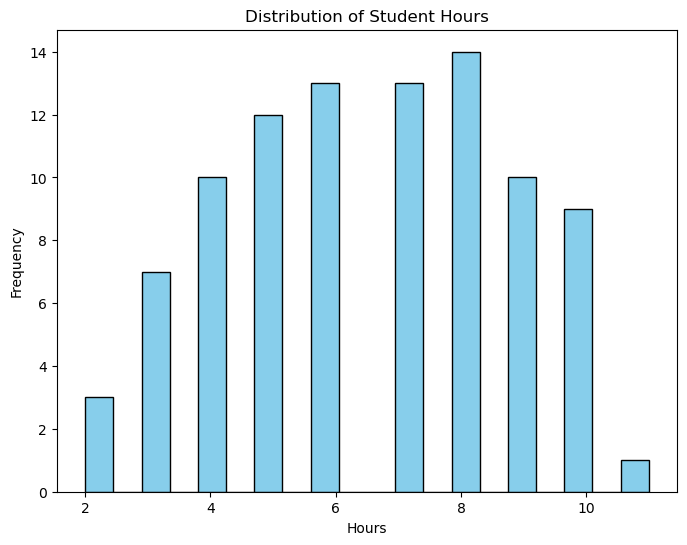

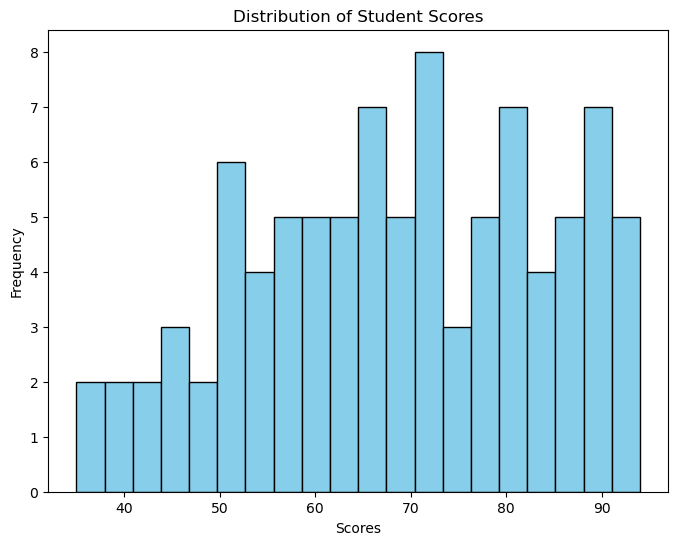

In [5]:
#Data Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist(x, bins=20,color='skyblue', edgecolor='black')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Student Hours')
plt.show()

plt.figure(figsize=(8,6))
plt.hist(y, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.title('Distribution of Student Scores')
plt.show()

In [6]:
#Split the data

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
    #stratify=y (to equally divide)
)

In [7]:
#Tain the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

print("Model Coefficient (Slope):", model.coef_[0])
print("Model Intercept:", model.intercept_)
#The coefficient indicates how much the score increases for every additional hour of study.

Model Coefficient (Slope): 6.804392044598462
Model Intercept: 24.61763598011151


In [8]:
#Make Predictions
y_pred = model.predict(x_test)
pred_data = {'y_prediction': y_pred.round(2),
             'y_test': y_test.reset_index(drop=True)}

prediction_table = pd.DataFrame(pred_data)

#User predictions to test
user_input = pd.DataFrame([[10]],columns=['hours'])
print(model.predict(user_input))

[92.66155643]


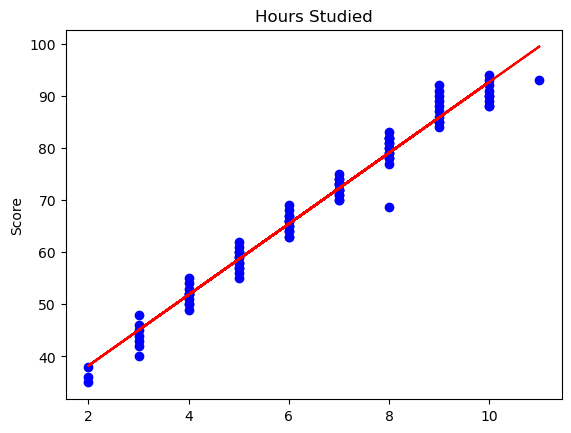

In [9]:
#Plot the line of Regression

import matplotlib.pyplot as plt
plt.scatter(x,y,color='blue')
plt.plot(x,model.predict(x), color='red')
plt.title("Hours Studied")
plt.ylabel("Score")
plt.show()

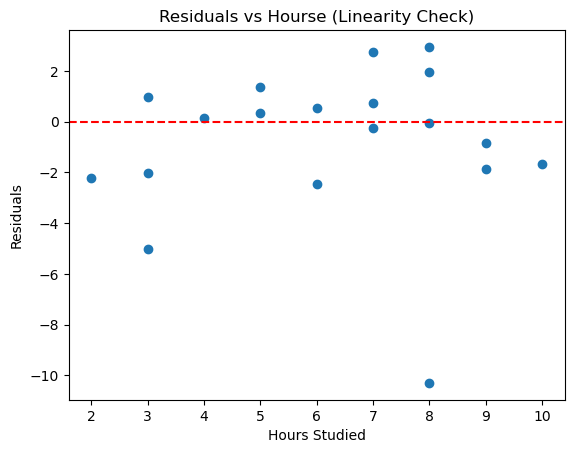

In [10]:
#Linear Regression Assumption

#Residuals
residuals = y_test - y_pred

#1. Linearity check (Residual vs x)
plt.scatter(x_test, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Hours Studied")
plt.ylabel("Residuals")
plt.title("Residuals vs Hourse (Linearity Check)")
plt.show()

In [11]:
#Evaluate the matrics

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np 

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)



In [12]:

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2 : {r2:.3f}")


MSE : 9.33
RMSE : 3.05
R^2 : 0.964


In [13]:
data

,name,hours,score,gender,grades,class
0,Aarav,8,68.758242,M,A,9A
1,Riya,5,62.000000,F,B,9B
2,Kabir,10,88.000000,M,A,10A
3,Sana,4,55.000000,F,C,9A
4,Vivaan,7,72.000000,M,B,10B
...,...,...,...,...,...,...
87,Prisha,4,52.000000,F,C,9A
88,Neil,10,88.000000,M,A,12C
89,Rutvi,7,73.000000,F,B,10A
90,Harshit,5,57.000000,M,C,9B
